# Import Libraries

In [2]:
# Basic libraries
import numpy as np
import pandas as pd

# Visualization 
import matplotlib.pyplot as plt
import seaborn as sns

# NLP & ML
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load Dataset

In [3]:
df = pd.read_csv("C:\\Users\\hp\\OneDrive\\ドキュメント\\OIBSIP\\Task 4 - Email spam Detection with Machine Learning\\spam.csv", encoding='latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


# Data Cleaning

In [4]:
# Keep only useful columns
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

# Convert labels: spam=1, ham=0
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


# Explore Data

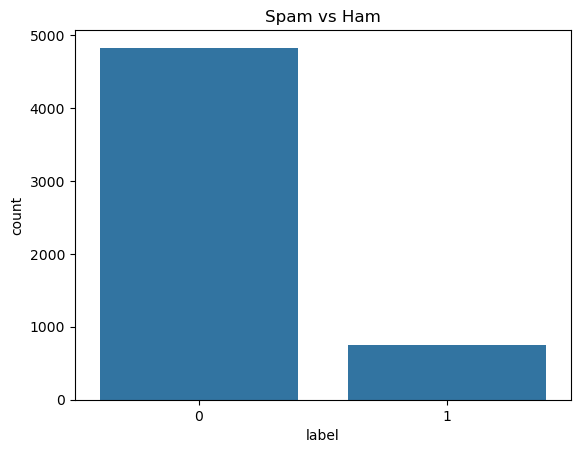

In [5]:
# Check distribution
df['label'].value_counts()

# Visualize
sns.countplot(x='label', data=df)
plt.title("Spam vs Ham")
plt.show()

# Convert Text → Numbers (Feature Extraction)

In [6]:
vectorizer = CountVectorizer()

X = vectorizer.fit_transform(df['message'])
y = df['label']

# Train-Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Model (Naive Bayes)

In [8]:
model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

# Predictions

In [9]:
y_pred = model.predict(X_test)

# Evaluate Model

In [10]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.97847533632287

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       965
           1       0.91      0.93      0.92       150

    accuracy                           0.98      1115
   macro avg       0.95      0.96      0.95      1115
weighted avg       0.98      0.98      0.98      1115


Confusion Matrix:

[[952  13]
 [ 11 139]]


# Test Custom Email

In [11]:
sample = ["Congratulations! You won a free lottery. Claim now!"]

sample_vector = vectorizer.transform(sample)
prediction = model.predict(sample_vector)

if prediction[0] == 1:
    print("Spam Email 🚨")
else:
    print("Not Spam ✅")

Spam Email 🚨
